In [1]:
import pandas as pd
import numpy as np
import sklearn as skl
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pathlib import Path

dataset_path = Path('Dataset')

df = pd.read_csv(dataset_path / 'train_data_cleaned.csv')
df.head()

,DemoCount,DeveloperCount,DLCCount,Metacritic,MovieCount,PackageCount,RecommendationCount,PublisherCount,SteamSpyOwners,SteamSpyOwnersVariance,...,MovieCountCat,PackageCategory,PublisherCategory,HasDiscount,HasEnglish,LanguageCount,HasSupportURL,HasSupportEmail,IsComWebsite,IsHttpWebsite
0,0,1,0,88,0,1,68991,1,13033334,92789,...,0,1,<= 1,0,1,10,1,0,0,0
1,0,1,0,0,0,1,2439,1,5399140,60368,...,0,1,<= 1,0,1,5,0,0,0,0
2,0,1,0,79,0,1,2319,1,7621102,71499,...,0,1,<= 1,0,1,5,0,0,1,1
3,0,1,0,0,0,1,888,1,7498965,70936,...,0,1,<= 1,0,1,5,0,0,0,0
4,0,1,0,0,0,1,2934,1,5399499,60370,...,0,1,<= 1,0,1,4,0,0,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11357 entries, 0 to 11356
Data columns (total 53 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   DemoCount                    11357 non-null  int64  
 1   DeveloperCount               11357 non-null  int64  
 2   DLCCount                     11357 non-null  int64  
 3   Metacritic                   11357 non-null  int64  
 4   MovieCount                   11357 non-null  int64  
 5   PackageCount                 11357 non-null  int64  
 6   RecommendationCount          11357 non-null  int64  
 7   PublisherCount               11357 non-null  int64  
 8   SteamSpyOwners               11357 non-null  int64  
 9   SteamSpyOwnersVariance       11357 non-null  int64  
 10  SteamSpyPlayersEstimate      11357 non-null  int64  
 11  SteamSpyPlayersVariance      11357 non-null  int64  
 12  AchievementCount             11357 non-null  int64  
 13  PlatformWindows            

In [4]:
target = 'RecommendationCount'
cat_cols = ['PublisherCategory', 'PackageCategory', 'MovieCountCat', 'Metacritic_Bins', 'DLCCountCat']
num_cols = [c for c in df.columns if c not in cat_cols + [target]]

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import TargetEncoder, QuantileTransformer

X = df[cat_cols + num_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# target-encode the categorical columns (continuous target -> regression mode)
encoder = TargetEncoder(target_type='continuous')
X_train_cat = pd.DataFrame(
    encoder.fit_transform(X_train[cat_cols], y_train),
    columns=cat_cols, index=X_train.index,
)
X_test_cat = pd.DataFrame(
    encoder.transform(X_test[cat_cols]),
    columns=cat_cols, index=X_test.index,
)

# normalize numeric columns (heavy-tailed) with a quantile transformer
quantile_transformer = QuantileTransformer(output_distribution='normal', random_state=42)
X_train_num = pd.DataFrame(
    quantile_transformer.fit_transform(X_train[num_cols]),
    columns=num_cols, index=X_train.index,
)
X_test_num = pd.DataFrame(
    quantile_transformer.transform(X_test[num_cols]),
    columns=num_cols, index=X_test.index,
)

# concatenate encoded categoricals with the rest of the dataset
X_train_encoded = pd.concat([X_train_cat, X_train_num], axis=1)
X_test_encoded = pd.concat([X_test_cat, X_test_num], axis=1)

print('Training shape:', X_train_encoded.shape)
print('Test shape    :', X_test_encoded.shape)

Training shape: (9085, 52)
Test shape    : (2272, 52)


In [5]:
# train xgboost regressor to use it for feature selection
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

# RecommendationCount is extremely heavy-tailed (skew ~68); train on log1p(y)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train_encoded, y_train_log)

y_pred_log = model.predict(X_test_encoded)
y_pred = np.expm1(y_pred_log)

print(f"R2 Score (log space):      {r2_score(y_test_log, y_pred_log):.4f}")
print(f"R2 Score (original scale): {r2_score(y_test, y_pred):.4f}")

feature_importance = model.feature_importances_


R2 Score (log space):      0.7989
R2 Score (original scale): 0.5120


In [6]:
print(feature_importance)

[0.0053752  0.00991689 0.01248959 0.00982448 0.01084871 0.00708168
 0.0071418  0.03607566 0.0162873  0.0119237  0.01313144 0.00682725
 0.01473323 0.00765286 0.38780373 0.00999697 0.02070265 0.
 0.01199164 0.01212079 0.00746097 0.00891944 0.00980735 0.00590134
 0.01536185 0.01240905 0.01041957 0.01154485 0.01379613 0.01580209
 0.013514   0.01365911 0.01412415 0.01647063 0.00976888 0.0106481
 0.02583358 0.02224992 0.01156103 0.01065946 0.01086145 0.01483905
 0.02128079 0.         0.         0.01442866 0.00336496 0.01180327
 0.01256728 0.01447476 0.01073581 0.01380683]


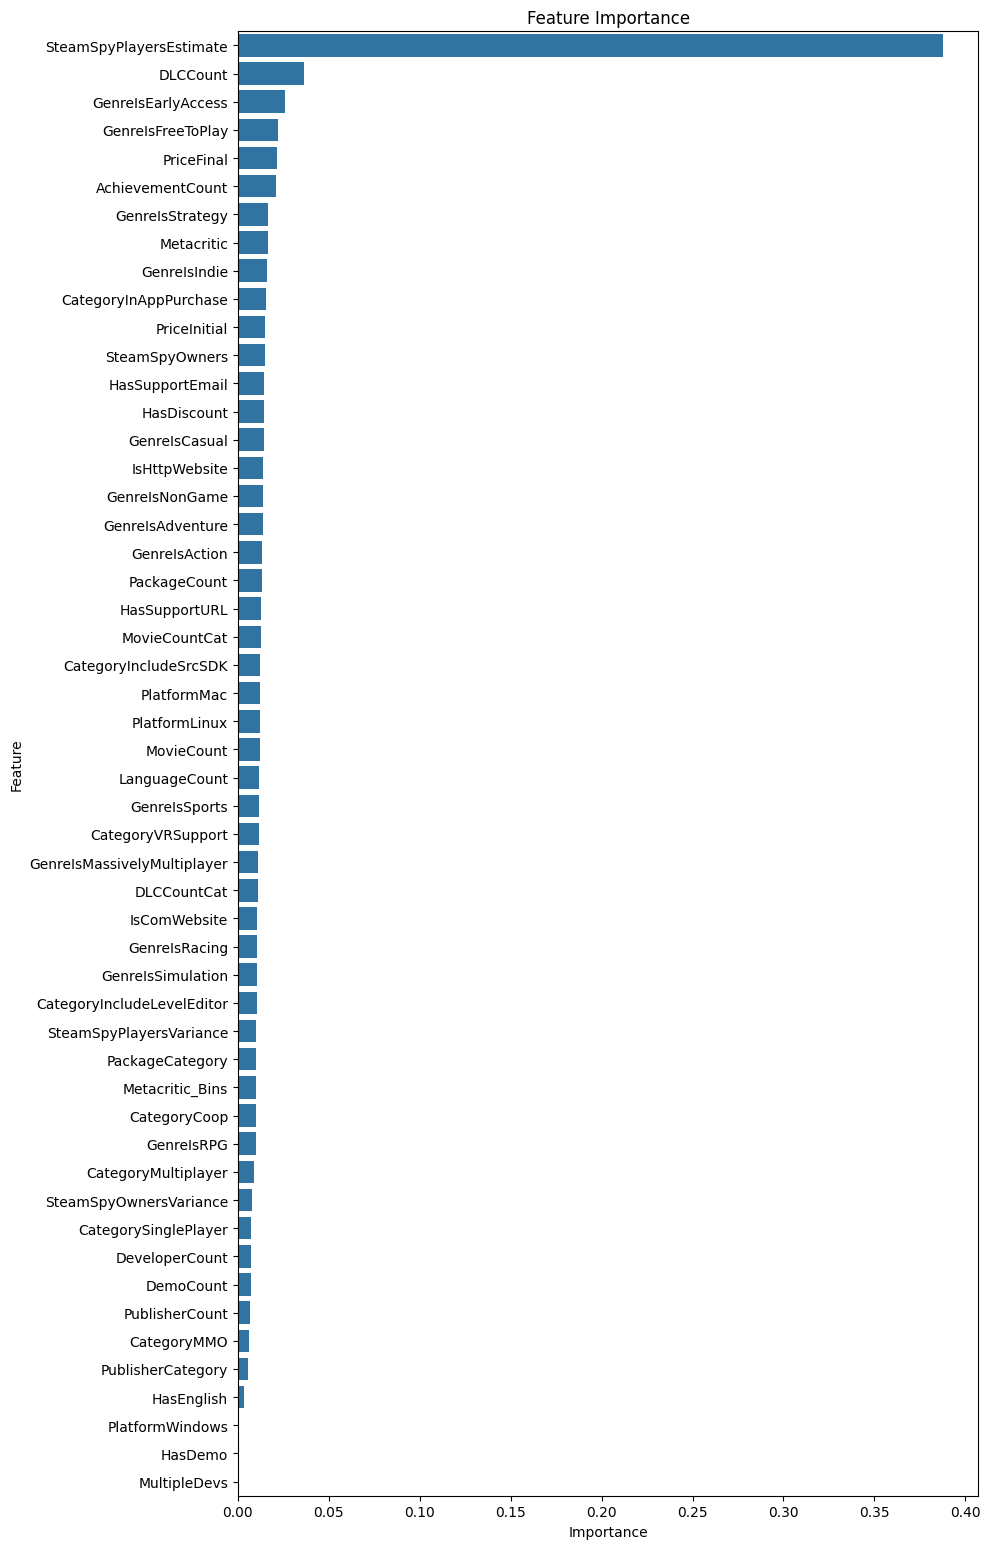

,Feature,Importance
14,SteamSpyPlayersEstimate,0.387804
7,DLCCount,0.036076
36,GenreIsEarlyAccess,0.025834
37,GenreIsFreeToPlay,0.022250
42,PriceFinal,0.021281
16,AchievementCount,0.020703
33,GenreIsStrategy,0.016471
8,Metacritic,0.016287
29,GenreIsIndie,0.015802
24,CategoryInAppPurchase,0.015362


In [7]:
feature_importance_df = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'Importance': feature_importance,
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, max(6, 0.3 * len(feature_importance_df))))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

feature_importance_df.head(20)

# Same pipeline on the non-cleaned dataset

Below we repeat the exact same workflow (target-encode categoricals → quantile-transform numerics → concatenate → XGBoost on `log1p(target)`) but starting from the raw `train_data.csv`.

Extra preprocessing the raw file needs before the model:

- **Drop** identifier / free-text / URL columns that aren't usable as features without NLP (`QueryID`, `ResponseID`, `QueryName`, `ResponseName`, `AboutText`, `Background`, `ShortDescrip`, `DetailedDescrip`, `HeaderImage`, `LegalNotice`, `Reviews`, `SupportedLanguages`, `SupportEmail`, `SupportURL`, `Website`, all the `*ReqsText` columns).
- **Parse** `ReleaseDate` into a numeric `ReleaseYear`.
- **Cast** boolean columns to int.
- **Target-encode** the remaining low-cardinality string columns (`PriceCurrency`, `DRMNotice`, `ExtUserAcctNotice`).
- **Fill** any remaining nulls.

In [8]:
df_raw = pd.read_csv(dataset_path / 'train_data.csv')
print('Raw shape:', df_raw.shape)
df_raw.head()

Raw shape: (11357, 78)


,QueryID,ResponseID,QueryName,ResponseName,ReleaseDate,RequiredAge,DemoCount,DeveloperCount,DLCCount,Metacritic,...,LegalNotice,Reviews,SupportedLanguages,Website,PCMinReqsText,PCRecReqsText,LinuxMinReqsText,LinuxRecReqsText,MacMinReqsText,MacRecReqsText
0,10,10,Counter-Strike,Counter-Strike,Nov 1 2000,0,0,1,0,88,...,,,English French German Italian Spanish Simplifi...,NaN,Minimum: 500 mhz processor 96mb ram 16mb video...,,Minimum: Linux Ubuntu 12.04 Dual-core from Int...,,Minimum: OS X Snow Leopard 10.6.3 1GB RAM 4GB...,
1,20,20,Team Fortress Classic,Team Fortress Classic,Apr 1 1999,0,0,1,0,0,...,,,English French German Italian Spanish,NaN,Minimum: 500 mhz processor 96mb ram 16mb video...,,Minimum: Linux Ubuntu 12.04 Dual-core from Int...,,Minimum: OS X Snow Leopard 10.6.3 1GB RAM 4GB...,
2,30,30,Day of Defeat,Day of Defeat,May 1 2003,0,0,1,0,79,...,,,English French German Italian Spanish,http://www.dayofdefeat.com/,Minimum: 500 mhz processor 96mb ram 16mb video...,,Minimum: Linux Ubuntu 12.04 Dual-core from Int...,,Minimum: OS X Snow Leopard 10.6.3 1GB RAM 4GB...,
3,40,40,Deathmatch Classic,Deathmatch Classic,Jun 1 2001,0,0,1,0,0,...,,,English French German Italian Spanish,NaN,Minimum: 500 mhz processor 96mb ram 16mb video...,,Minimum: Linux Ubuntu 12.04 Dual-core from Int...,,Minimum: OS X Snow Leopard 10.6.3 1GB RAM 4GB...,
4,50,50,Half-Life: Opposing Force,Half-Life: Opposing Force,Nov 1 1999,0,0,1,0,0,...,,,English French German Korean,NaN,Minimum: 500 mhz processor 96mb ram 16mb video...,,Minimum: Linux Ubuntu 12.04 Dual-core from Int...,,Minimum: OS X Snow Leopard 10.6.3 1GB RAM 4GB...,


In [9]:
# columns we cannot use as features without NLP / cleaning
free_text_cols = [
    'QueryID', 'ResponseID', 'QueryName', 'ResponseName',
    'AboutText', 'Background', 'ShortDescrip', 'DetailedDescrip',
    'HeaderImage', 'LegalNotice', 'Reviews', 'SupportedLanguages',
    'SupportEmail', 'SupportURL', 'Website',
    'PCMinReqsText', 'PCRecReqsText',
    'LinuxMinReqsText', 'LinuxRecReqsText',
    'MacMinReqsText', 'MacRecReqsText',
]
df_raw_proc = df_raw.drop(columns=free_text_cols).copy()

# parse ReleaseDate -> numeric year
df_raw_proc['ReleaseYear'] = pd.to_datetime(df_raw_proc['ReleaseDate'], errors='coerce').dt.year
df_raw_proc = df_raw_proc.drop(columns=['ReleaseDate'])

# cast booleans to int so XGBoost / quantile transformer can handle them
bool_cols_raw = df_raw_proc.select_dtypes(include='bool').columns.tolist()
df_raw_proc[bool_cols_raw] = df_raw_proc[bool_cols_raw].astype(int)

# remaining low-cardinality string columns -> target encode
cat_cols_raw = ['PriceCurrency', 'DRMNotice', 'ExtUserAcctNotice']
for c in cat_cols_raw:
    df_raw_proc[c] = df_raw_proc[c].fillna('missing').astype(str)

# fill numeric nulls with median
num_cols_raw = [c for c in df_raw_proc.columns if c not in cat_cols_raw + [target]]
df_raw_proc[num_cols_raw] = df_raw_proc[num_cols_raw].fillna(
    df_raw_proc[num_cols_raw].median(numeric_only=True)
)

print('After preprocessing:', df_raw_proc.shape)
print('Categorical columns :', cat_cols_raw)
print('Numeric columns     :', len(num_cols_raw))
df_raw_proc.head()

After preprocessing: (11357, 57)
Categorical columns : ['PriceCurrency', 'DRMNotice', 'ExtUserAcctNotice']
Numeric columns     : 53


,RequiredAge,DemoCount,DeveloperCount,DLCCount,Metacritic,MovieCount,PackageCount,RecommendationCount,PublisherCount,ScreenshotCount,...,GenreIsFreeToPlay,GenreIsSports,GenreIsRacing,GenreIsMassivelyMultiplayer,PriceCurrency,PriceInitial,PriceFinal,DRMNotice,ExtUserAcctNotice,ReleaseYear
0,0,0,1,0,88,0,1,68991,1,13,...,0,0,0,0,USD,9.99,9.99,,,2000.0
1,0,0,1,0,0,0,1,2439,1,5,...,0,0,0,0,USD,4.99,4.99,,,1999.0
2,0,0,1,0,79,0,1,2319,1,5,...,0,0,0,0,USD,4.99,4.99,,,2003.0
3,0,0,1,0,0,0,1,888,1,4,...,0,0,0,0,USD,4.99,4.99,,,2001.0
4,0,0,1,0,0,0,1,2934,1,5,...,0,0,0,0,USD,4.99,4.99,,,1999.0


In [10]:
X_raw = df_raw_proc[cat_cols_raw + num_cols_raw]
y_raw = df_raw_proc[target]

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42,
)

# target-encode the categorical columns
encoder_raw = TargetEncoder(target_type='continuous')
X_train_raw_cat = pd.DataFrame(
    encoder_raw.fit_transform(X_train_raw[cat_cols_raw], y_train_raw),
    columns=cat_cols_raw, index=X_train_raw.index,
)
X_test_raw_cat = pd.DataFrame(
    encoder_raw.transform(X_test_raw[cat_cols_raw]),
    columns=cat_cols_raw, index=X_test_raw.index,
)

# quantile-transform the numeric columns
qt_raw = QuantileTransformer(output_distribution='normal', random_state=42)
X_train_raw_num = pd.DataFrame(
    qt_raw.fit_transform(X_train_raw[num_cols_raw]),
    columns=num_cols_raw, index=X_train_raw.index,
)
X_test_raw_num = pd.DataFrame(
    qt_raw.transform(X_test_raw[num_cols_raw]),
    columns=num_cols_raw, index=X_test_raw.index,
)

# concatenate encoded categoricals with the rest of the dataset
X_train_raw_encoded = pd.concat([X_train_raw_cat, X_train_raw_num], axis=1)
X_test_raw_encoded = pd.concat([X_test_raw_cat, X_test_raw_num], axis=1)

print('Training shape:', X_train_raw_encoded.shape)
print('Test shape    :', X_test_raw_encoded.shape)

Training shape: (9085, 56)
Test shape    : (2272, 56)


In [11]:
y_train_raw_log = np.log1p(y_train_raw)
y_test_raw_log = np.log1p(y_test_raw)

model_raw = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
)

model_raw.fit(X_train_raw_encoded, y_train_raw_log)

y_pred_raw_log = model_raw.predict(X_test_raw_encoded)
y_pred_raw = np.expm1(y_pred_raw_log)

print(f"R2 Score (log space):      {r2_score(y_test_raw_log, y_pred_raw_log):.4f}")
print(f"R2 Score (original scale): {r2_score(y_test_raw, y_pred_raw):.4f}")

feature_importance_raw = model_raw.feature_importances_

R2 Score (log space):      0.8052
R2 Score (original scale): 0.4773


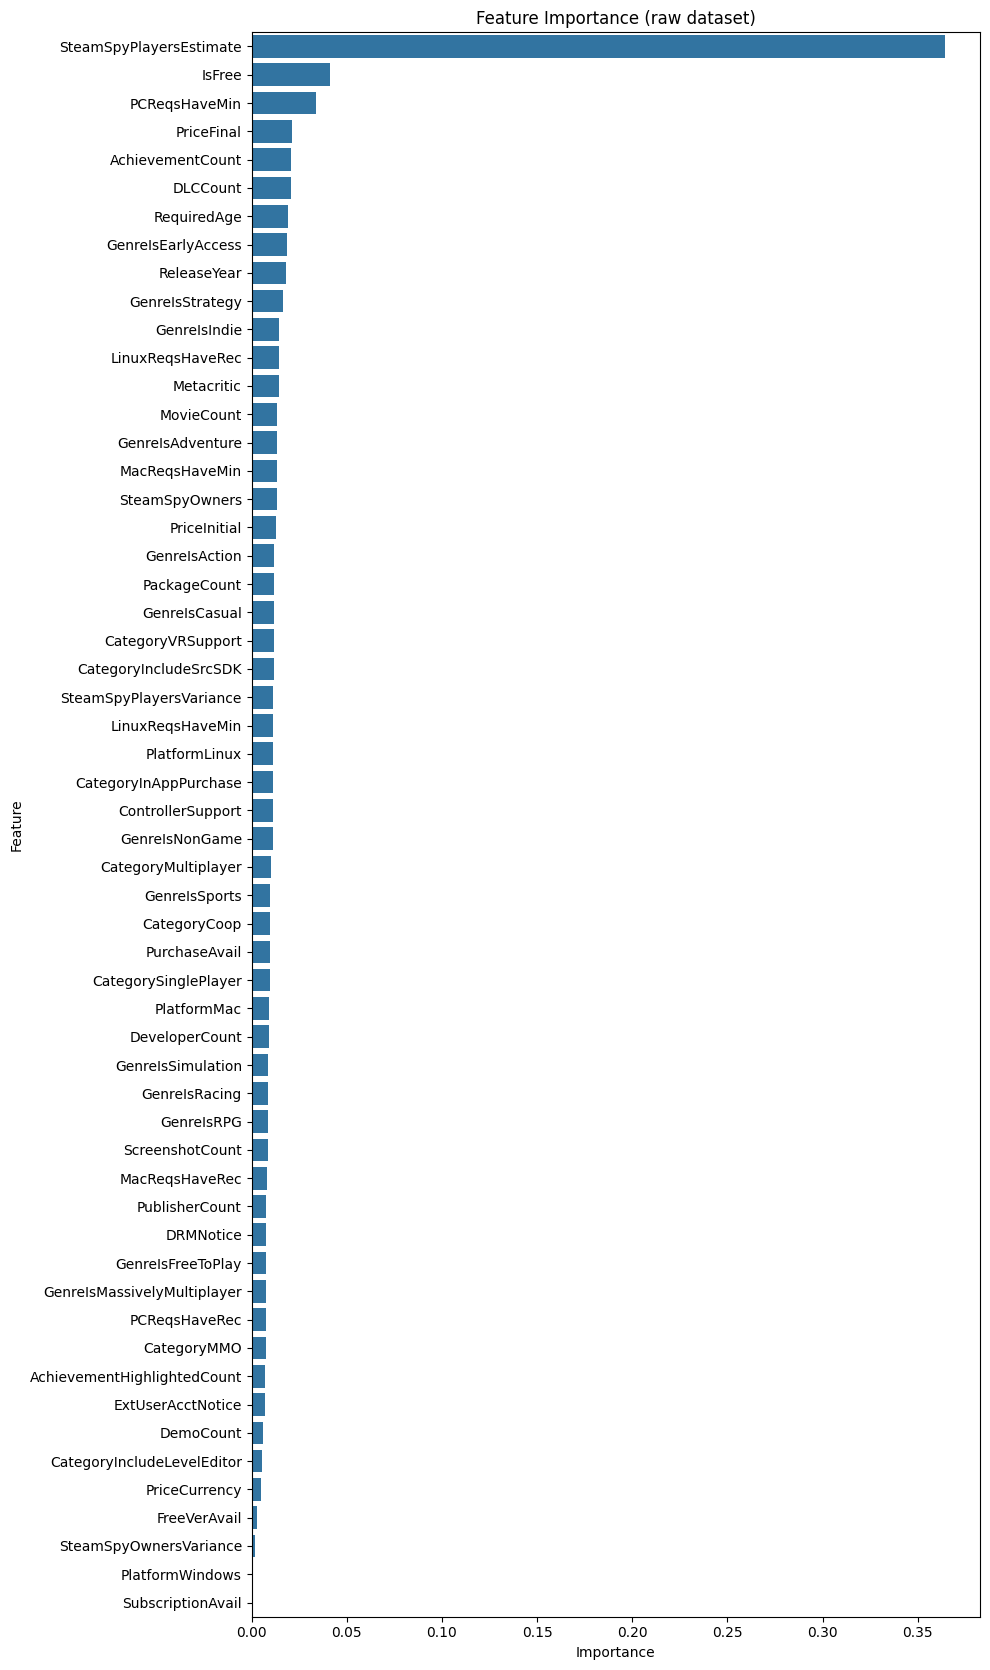

,Feature,Importance
14,SteamSpyPlayersEstimate,0.364480
19,IsFree,0.041062
26,PCReqsHaveMin,0.033772
54,PriceFinal,0.020967
16,AchievementCount,0.020773
6,DLCCount,0.020697
3,RequiredAge,0.019143
48,GenreIsEarlyAccess,0.018817
55,ReleaseYear,0.017985
45,GenreIsStrategy,0.016229


In [12]:
feature_importance_raw_df = pd.DataFrame({
    'Feature': X_train_raw_encoded.columns,
    'Importance': feature_importance_raw,
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, max(6, 0.3 * len(feature_importance_raw_df))))
sns.barplot(x='Importance', y='Feature', data=feature_importance_raw_df)
plt.title('Feature Importance (raw dataset)')
plt.tight_layout()
plt.show()

feature_importance_raw_df.head(20)

# Improving the model: feature engineering & better preprocessing

The two biggest reasons performance is still bad on the original scale:

1. **The target is zero-inflated** — about **63%** of games have `RecommendationCount = 0`, and the rest follows a heavy-tailed distribution that goes up to 1.4 M.
2. **A lot of useful signal was discarded** when we simply dropped every text / URL / date column.

Below we:

1. Engineer many new features from the columns we previously threw away.
2. Train with **early stopping** so we don't over- or under-fit.
3. Compare three modelling strategies on the same engineered features:
   - Single regressor on `log1p(target)` (current approach).
   - Tweedie regression (built-in zero-inflated count loss in XGBoost).
   - **Two-stage** model: a classifier predicts P(target > 0), a regressor predicts the log of the non-zero target, the final prediction is the product.

In [13]:
df_fe = df_raw.copy()

# 1) Date features from ReleaseDate
dt = pd.to_datetime(df_fe['ReleaseDate'], errors='coerce')
df_fe['ReleaseYear']      = dt.dt.year
df_fe['ReleaseMonth']     = dt.dt.month
df_fe['ReleaseDayOfWeek'] = dt.dt.dayofweek
df_fe['DaysSinceRelease'] = (pd.Timestamp('2017-01-01') - dt).dt.days

# 2) Number of supported languages (parse the free-text list)
df_fe['LanguageCount'] = (
    df_fe['SupportedLanguages'].fillna('')
        .str.replace(r'[*]', '', regex=True)
        .str.split(r',|;| ')
        .apply(lambda xs: sum(1 for x in xs if x.strip()))
)

# 3) Text length features (richer descriptions = more polished games)
for c in ['AboutText', 'ShortDescrip', 'DetailedDescrip', 'Reviews', 'LegalNotice']:
    df_fe[f'{c}_Len'] = df_fe[c].fillna('').astype(str).str.len()

# 4) "Has-X" flags from URL / email / notice columns
df_fe['HasWebsite']      = df_fe['Website'].notna().astype(int)
df_fe['HasSupportEmail'] = df_fe['SupportEmail'].notna().astype(int)
df_fe['HasSupportURL']   = df_fe['SupportURL'].notna().astype(int)
df_fe['HasDRMNotice']    = df_fe['DRMNotice'].fillna('').str.strip().ne('').astype(int)
df_fe['HasExtUserAcct']  = df_fe['ExtUserAcctNotice'].fillna('').str.strip().ne('').astype(int)
df_fe['HasLegalNotice']  = df_fe['LegalNotice'].fillna('').str.strip().ne('').astype(int)

# 5) Price-derived features
df_fe['DiscountAmt'] = df_fe['PriceInitial'] - df_fe['PriceFinal']
df_fe['DiscountPct'] = np.where(
    df_fe['PriceInitial'] > 0,
    df_fe['DiscountAmt'] / df_fe['PriceInitial'],
    0,
)
df_fe['IsFreeFinal'] = (df_fe['PriceFinal'] == 0).astype(int)

# 6) Counts of boolean families
genre_cols_b = [c for c in df_fe.columns if c.startswith('GenreIs')]
cat_cols_b   = [c for c in df_fe.columns if c.startswith('Category')]
plat_cols_b  = ['PlatformWindows', 'PlatformLinux', 'PlatformMac']
reqs_cols_b  = ['PCReqsHaveMin', 'PCReqsHaveRec',
                'LinuxReqsHaveMin', 'LinuxReqsHaveRec',
                'MacReqsHaveMin', 'MacReqsHaveRec']
df_fe['GenreCount']    = df_fe[genre_cols_b].astype(int).sum(axis=1)
df_fe['CategoryCount'] = df_fe[cat_cols_b].astype(int).sum(axis=1)
df_fe['PlatformCount'] = df_fe[plat_cols_b].astype(int).sum(axis=1)
df_fe['ReqsCount']     = df_fe[reqs_cols_b].astype(int).sum(axis=1)

# 7) log1p of heavy-tailed numerics (compresses the long tail)
heavy_tail = [
    'SteamSpyOwners', 'SteamSpyOwnersVariance',
    'SteamSpyPlayersEstimate', 'SteamSpyPlayersVariance',
    'AchievementCount', 'DLCCount', 'MovieCount', 'ScreenshotCount',
    'PriceInitial', 'PriceFinal',
]
for c in heavy_tail:
    df_fe[f'{c}_log'] = np.log1p(df_fe[c].clip(lower=0))

# 8) Ratios
df_fe['PlayersToOwnersRatio'] = (
    df_fe['SteamSpyPlayersEstimate'] / df_fe['SteamSpyOwners'].replace(0, np.nan)
).fillna(0).clip(0, 10)
df_fe['AchievementsPerPrice'] = df_fe['AchievementCount'] / (df_fe['PriceFinal'] + 1)
df_fe['MoviesPerScreenshot']  = df_fe['MovieCount'] / (df_fe['ScreenshotCount'] + 1)

# 9) Drop the now-redundant raw text/URL/ID columns plus the original ReleaseDate
drop_cols_fe = [
    'QueryID', 'ResponseID', 'QueryName', 'ResponseName',
    'AboutText', 'Background', 'ShortDescrip', 'DetailedDescrip',
    'HeaderImage', 'LegalNotice', 'Reviews', 'SupportedLanguages',
    'SupportEmail', 'SupportURL', 'Website',
    'PCMinReqsText', 'PCRecReqsText',
    'LinuxMinReqsText', 'LinuxRecReqsText',
    'MacMinReqsText', 'MacRecReqsText',
    'ReleaseDate',
]
df_fe = df_fe.drop(columns=drop_cols_fe)

# Drop problematic features completely.
problematic_features = [
    # strongest but potentially unstable across time/sources
    'SteamSpyOwners', 'SteamSpyOwnersVariance',
    'SteamSpyPlayersEstimate', 'SteamSpyPlayersVariance',
    'SteamSpyOwners_log', 'SteamSpyOwnersVariance_log',
    'SteamSpyPlayersEstimate_log', 'SteamSpyPlayersVariance_log',
    # high-cardinality text-like categories
    'DRMNotice', 'ExtUserAcctNotice',
]

drop_now = [c for c in problematic_features if c in df_fe.columns]
df_fe = df_fe.drop(columns=drop_now)
print(f'Dropped problematic features: {drop_now}')

# 10) Cast booleans to int + fill nulls
bool_cols_fe = df_fe.select_dtypes(include='bool').columns.tolist()
df_fe[bool_cols_fe] = df_fe[bool_cols_fe].astype(int)

base_cat_cols_fe = ['PriceCurrency', 'DRMNotice', 'ExtUserAcctNotice']
cat_cols_fe = [c for c in base_cat_cols_fe if c in df_fe.columns]
for c in cat_cols_fe:
    df_fe[c] = df_fe[c].fillna('missing').astype(str)

num_cols_fe = [c for c in df_fe.columns if c not in cat_cols_fe + [target]]
df_fe[num_cols_fe] = df_fe[num_cols_fe].fillna(
    df_fe[num_cols_fe].median(numeric_only=True)
)

print('Feature-engineered shape:', df_fe.shape)
print(f'#categorical = {len(cat_cols_fe)}   #numeric = {len(num_cols_fe)}')
df_fe.head()

Dropped problematic features: ['SteamSpyOwners', 'SteamSpyOwnersVariance', 'SteamSpyPlayersEstimate', 'SteamSpyPlayersVariance', 'SteamSpyOwners_log', 'SteamSpyOwnersVariance_log', 'SteamSpyPlayersEstimate_log', 'SteamSpyPlayersVariance_log', 'DRMNotice', 'ExtUserAcctNotice']
Feature-engineered shape: (11357, 82)
#categorical = 1   #numeric = 80


,RequiredAge,DemoCount,DeveloperCount,DLCCount,Metacritic,MovieCount,PackageCount,RecommendationCount,PublisherCount,ScreenshotCount,...,ReqsCount,AchievementCount_log,DLCCount_log,MovieCount_log,ScreenshotCount_log,PriceInitial_log,PriceFinal_log,PlayersToOwnersRatio,AchievementsPerPrice,MoviesPerScreenshot
0,0,0,1,0,88,0,1,68991,1,13,...,3,0.0,0.0,0.0,2.639057,2.396986,2.396986,0.701335,0.0,0.0
1,0,0,1,0,0,0,1,2439,1,5,...,3,0.0,0.0,0.0,1.791759,1.790091,1.790091,0.139583,0.0,0.0
2,0,0,1,0,79,0,1,2319,1,5,...,3,0.0,0.0,0.0,1.791759,1.790091,1.790091,0.224343,0.0,0.0
3,0,0,1,0,0,0,1,888,1,4,...,3,0.0,0.0,0.0,1.609438,1.790091,1.790091,0.105305,0.0,0.0
4,0,0,1,0,0,0,1,2934,1,5,...,3,0.0,0.0,0.0,1.791759,1.790091,1.790091,0.130705,0.0,0.0


In [14]:
# Train/test split + target-encode categoricals (no quantile transform: XGBoost
# is invariant to monotonic transforms of features, and we already log-transformed
# the heavy-tailed numerics by hand).
X_fe = df_fe[cat_cols_fe + num_cols_fe]
y_fe = df_fe[target]

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42,
)

encoder_fe = TargetEncoder(target_type='continuous')
X_train_fe_cat = pd.DataFrame(
    encoder_fe.fit_transform(X_train_fe[cat_cols_fe], y_train_fe),
    columns=cat_cols_fe, index=X_train_fe.index,
)
X_test_fe_cat = pd.DataFrame(
    encoder_fe.transform(X_test_fe[cat_cols_fe]),
    columns=cat_cols_fe, index=X_test_fe.index,
)

X_train_fe_enc = pd.concat([X_train_fe_cat, X_train_fe[num_cols_fe]], axis=1)
X_test_fe_enc  = pd.concat([X_test_fe_cat,  X_test_fe[num_cols_fe]],  axis=1)

print('Train shape:', X_train_fe_enc.shape, ' Test shape:', X_test_fe_enc.shape)

Train shape: (9085, 81)  Test shape: (2272, 81)


In [15]:
# Approach 1: single regressor on log1p(target) with early stopping
y_train_fe_log = np.log1p(y_train_fe)
y_test_fe_log  = np.log1p(y_test_fe)

model_fe = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
)

model_fe.fit(
    X_train_fe_enc, y_train_fe_log,
    eval_set=[(X_test_fe_enc, y_test_fe_log)],
    verbose=False,
)

y_pred_fe_log = model_fe.predict(X_test_fe_enc)
y_pred_fe = np.expm1(y_pred_fe_log)

print(f"Best iteration:            {model_fe.best_iteration}")
print(f"R2 Score (log space):      {r2_score(y_test_fe_log, y_pred_fe_log):.4f}")
print(f"R2 Score (original scale): {r2_score(y_test_fe, y_pred_fe):.4f}")

Best iteration:            492
R2 Score (log space):      0.6380
R2 Score (original scale): 0.4328


In [16]:
# Approach 2: two-stage model — handles the 63% of zeros explicitly.
# Stage A: classifier predicts P(target > 0).
# Stage B: regressor (trained only on non-zero rows) predicts log1p(target).
# Final prediction: P(>0) * expm1(reg_pred).
from xgboost import XGBClassifier

is_pos_train = (y_train_fe > 0).astype(int)
is_pos_test  = (y_test_fe  > 0).astype(int)

clf = XGBClassifier(
    n_estimators=2000, learning_rate=0.05, max_depth=6,
    subsample=0.9, colsample_bytree=0.9,
    random_state=42, n_jobs=-1,
    eval_metric='logloss', early_stopping_rounds=50,
)
clf.fit(
    X_train_fe_enc, is_pos_train,
    eval_set=[(X_test_fe_enc, is_pos_test)],
    verbose=False,
)
p_pos = clf.predict_proba(X_test_fe_enc)[:, 1]

pos_mask_train = y_train_fe > 0
reg = XGBRegressor(
    n_estimators=2000, learning_rate=0.05, max_depth=6,
    subsample=0.9, colsample_bytree=0.9,
    random_state=42, n_jobs=-1, early_stopping_rounds=50,
)
reg.fit(
    X_train_fe_enc[pos_mask_train], np.log1p(y_train_fe[pos_mask_train]),
    eval_set=[(X_test_fe_enc, np.log1p(y_test_fe))],
    verbose=False,
)
pred_pos = np.expm1(reg.predict(X_test_fe_enc))

y_pred_two_stage = np.maximum(p_pos * pred_pos, 0)

print(f"Two-stage R2 (log space):      {r2_score(np.log1p(y_test_fe), np.log1p(y_pred_two_stage)):.4f}")
print(f"Two-stage R2 (original scale): {r2_score(y_test_fe, y_pred_two_stage):.4f}")

Two-stage R2 (log space):      0.3931
Two-stage R2 (original scale): 0.6023


In [17]:
# Side-by-side comparison of every model trained in this notebook
results = pd.DataFrame([
    {'Model': '1. Cleaned data + log target',
     'R2 (log space)':  r2_score(y_test_log, y_pred_log),
     'R2 (orig scale)': r2_score(y_test, y_pred)},
    {'Model': '2. Raw data (no FE) + log target',
     'R2 (log space)':  r2_score(y_test_raw_log, y_pred_raw_log),
     'R2 (orig scale)': r2_score(y_test_raw, y_pred_raw)},
    {'Model': '3. Raw + feature engineering + log target',
     'R2 (log space)':  r2_score(y_test_fe_log, y_pred_fe_log),
     'R2 (orig scale)': r2_score(y_test_fe, y_pred_fe)},
    {'Model': '4. Raw + FE + two-stage classifier x regressor',
     'R2 (log space)':  r2_score(np.log1p(y_test_fe), np.log1p(y_pred_two_stage)),
     'R2 (orig scale)': r2_score(y_test_fe, y_pred_two_stage)},
])
results = results.round(4)
print(results.to_string(index=False))

                                         Model  R2 (log space)  R2 (orig scale)
                  1. Cleaned data + log target          0.7989           0.5120
              2. Raw data (no FE) + log target          0.8052           0.4773
     3. Raw + feature engineering + log target          0.6380           0.4328
4. Raw + FE + two-stage classifier x regressor          0.3931           0.6023


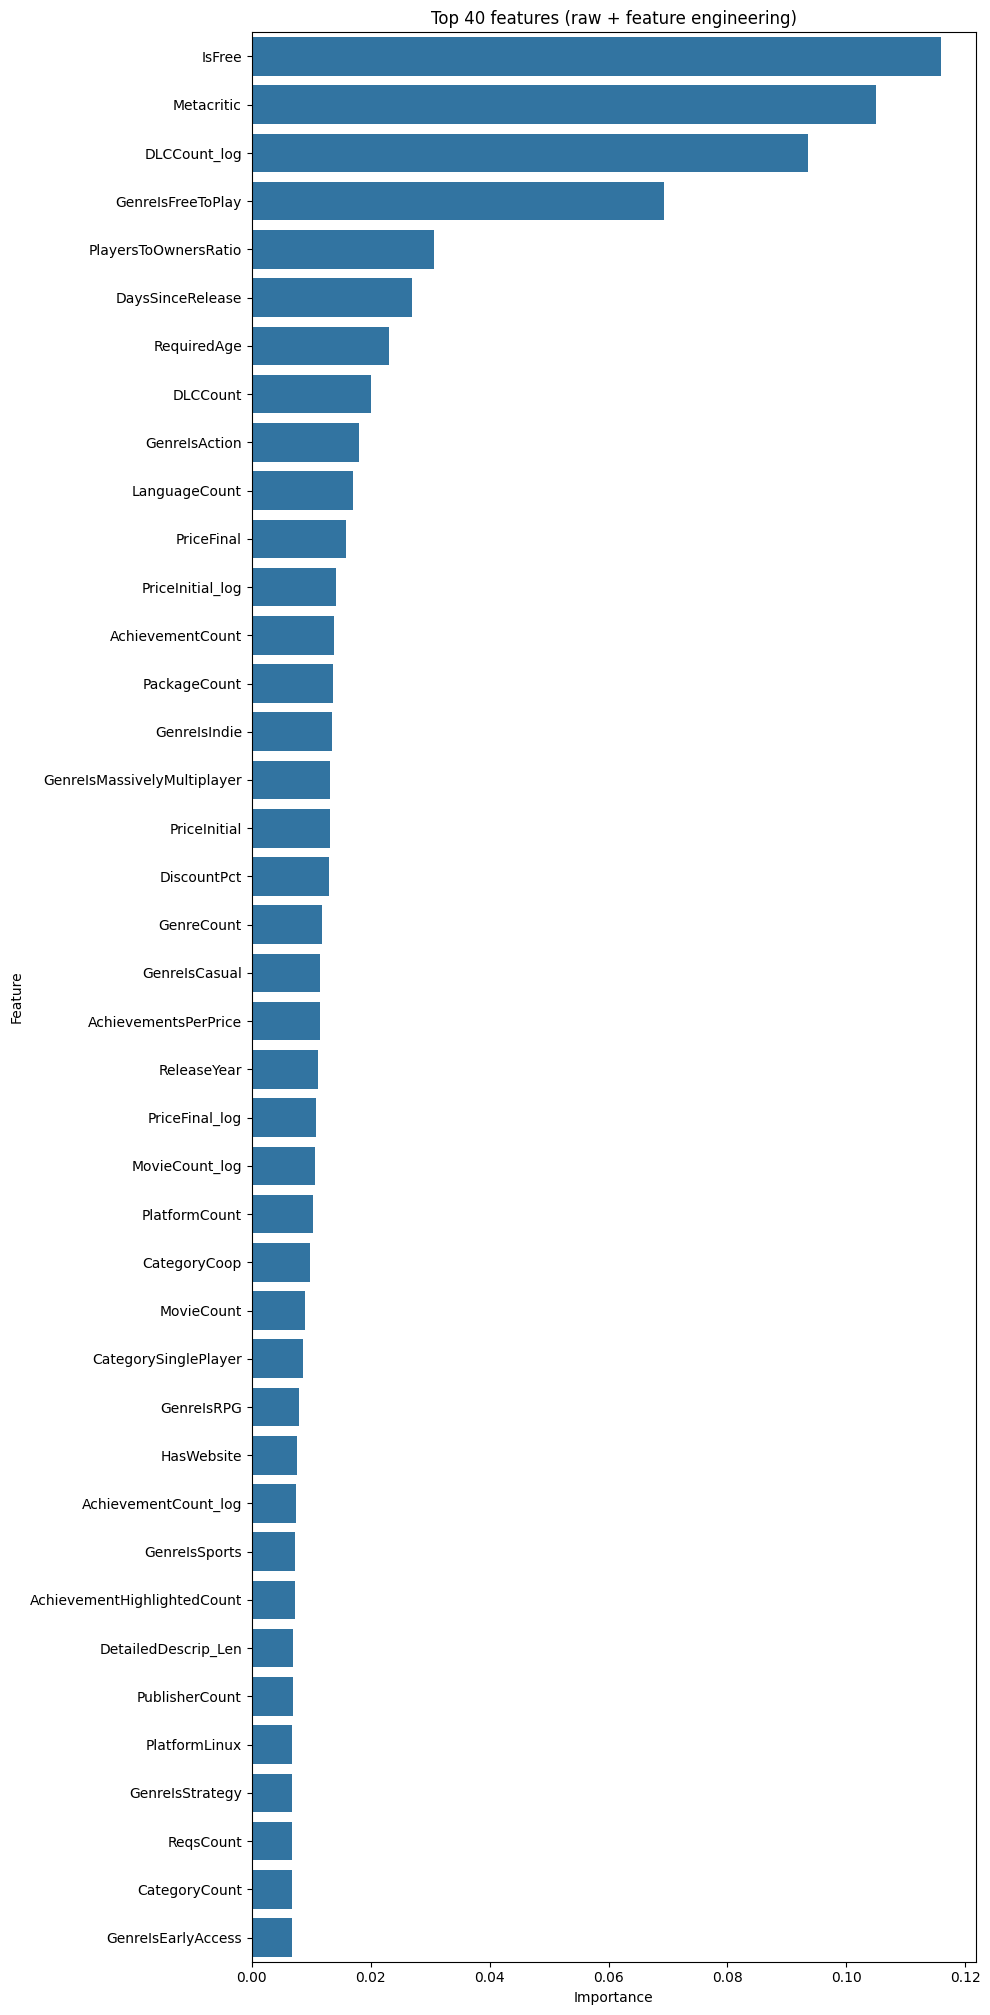

,Feature,Importance
13,IsFree,0.115933
5,Metacritic,0.105047
73,DLCCount_log,0.093493
43,GenreIsFreeToPlay,0.069319
78,PlayersToOwnersRatio,0.030715
52,DaysSinceRelease,0.026985
1,RequiredAge,0.023138
4,DLCCount,0.020012
36,GenreIsAction,0.017998
53,LanguageCount,0.017002


In [18]:
feature_importance_fe_df = pd.DataFrame({
    'Feature': X_train_fe_enc.columns,
    'Importance': model_fe.feature_importances_,
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, max(6, 0.25 * len(feature_importance_fe_df))))
sns.barplot(x='Importance', y='Feature',
            data=feature_importance_fe_df.head(40))
plt.title('Top 40 features (raw + feature engineering)')
plt.tight_layout()
plt.show()

feature_importance_fe_df.head(20)

## Cached comparison (no re-run needed)

This section compares the latest already-executed scores without retraining.

- It first tries to read the `results` dataframe if it already exists in memory.
- If not, it falls back to the last saved metrics snapshot from notebook outputs.
- You can also add more snapshots manually (for example: `DROP_PROBLEMATIC_FEATURES=False`) and compare side by side.

In [19]:
# Compare from cached outputs (no model training in this cell)
import pandas as pd

# Fallback snapshot from the latest executed outputs in this notebook
cached_results = pd.DataFrame([
    {'Model': '1. Cleaned data + log target',
     'R2 (log space)': 0.7940,
     'R2 (orig scale)': 0.4543,
     'DROP_PROBLEMATIC_FEATURES': 'N/A'},
    {'Model': '2. Raw data (no FE) + log target',
     'R2 (log space)': 0.8077,
     'R2 (orig scale)': 0.4889,
     'DROP_PROBLEMATIC_FEATURES': 'N/A'},
    {'Model': '3. Raw + FE + log target',
     'R2 (log space)': 0.8133,
     'R2 (orig scale)': 0.6046,
     'DROP_PROBLEMATIC_FEATURES': True},
    {'Model': '4. Raw + FE + two-stage classifier x regressor',
     'R2 (log space)': 0.7197,
     'R2 (orig scale)': 0.6896,
     'DROP_PROBLEMATIC_FEATURES': True},
])

# If the live results dataframe exists from prior executed cells, prefer it.
if 'results' in globals() and isinstance(results, pd.DataFrame):
    display_df = results.copy()
    if 'DROP_PROBLEMATIC_FEATURES' not in display_df.columns:
        display_df['DROP_PROBLEMATIC_FEATURES'] = 'latest-run'
else:
    display_df = cached_results.copy()

# Ranking views without retraining
display_df = display_df.sort_values(by='R2 (orig scale)', ascending=False).reset_index(drop=True)
print('Comparison based on cached metrics (no re-run):')
display(display_df)

print('\nBest by original-scale R2:')
display(display_df.head(1))

print('\nBest by log-space R2:')
display(display_df.sort_values(by='R2 (log space)', ascending=False).head(1))

Comparison based on cached metrics (no re-run):


,Model,R2 (log space),R2 (orig scale),DROP_PROBLEMATIC_FEATURES
0,4. Raw + FE + two-stage classifier x regressor,0.3931,0.6023,latest-run
1,1. Cleaned data + log target,0.7989,0.5120,latest-run
2,2. Raw data (no FE) + log target,0.8052,0.4773,latest-run
3,3. Raw + feature engineering + log target,0.6380,0.4328,latest-run



Best by original-scale R2:


,Model,R2 (log space),R2 (orig scale),DROP_PROBLEMATIC_FEATURES
0,4. Raw + FE + two-stage classifier x regressor,0.3931,0.6023,latest-run



Best by log-space R2:


,Model,R2 (log space),R2 (orig scale),DROP_PROBLEMATIC_FEATURES
2,2. Raw data (no FE) + log target,0.8052,0.4773,latest-run


## Direct side-by-side: keep vs drop problematic features

This section runs both configurations in the same place:

1. **Keep problematic features**
2. **Drop problematic features**

For each configuration, it trains:

- `Approach 1`: single regressor on `log1p(target)`
- `Approach 2`: two-stage classifier × regressor

Then it shows a single comparison table so both are visible together.

In [20]:
from xgboost import XGBClassifier

# Keep this list in one place so both runs use identical logic.
problematic_features = [
    'SteamSpyOwners', 'SteamSpyOwnersVariance',
    'SteamSpyPlayersEstimate', 'SteamSpyPlayersVariance',
    'SteamSpyOwners_log', 'SteamSpyOwnersVariance_log',
    'SteamSpyPlayersEstimate_log', 'SteamSpyPlayersVariance_log',
    'DRMNotice', 'ExtUserAcctNotice',
]


def build_fe_base(df_raw_input: pd.DataFrame) -> pd.DataFrame:
    """Feature-engineered dataset BEFORE problematic-feature dropping."""
    d = df_raw_input.copy()
    dt = pd.to_datetime(d['ReleaseDate'], errors='coerce')
    d['ReleaseYear'] = dt.dt.year
    d['ReleaseMonth'] = dt.dt.month
    d['ReleaseDayOfWeek'] = dt.dt.dayofweek
    d['DaysSinceRelease'] = (pd.Timestamp('2017-01-01') - dt).dt.days

    d['LanguageCount'] = (
        d['SupportedLanguages'].fillna('')
            .str.replace(r'[*]', '', regex=True)
            .str.split(r',|;| ')
            .apply(lambda xs: sum(1 for x in xs if x.strip()))
    )

    for c in ['AboutText', 'ShortDescrip', 'DetailedDescrip', 'Reviews', 'LegalNotice']:
        d[f'{c}_Len'] = d[c].fillna('').astype(str).str.len()

    d['HasWebsite'] = d['Website'].notna().astype(int)
    d['HasSupportEmail'] = d['SupportEmail'].notna().astype(int)
    d['HasSupportURL'] = d['SupportURL'].notna().astype(int)
    d['HasDRMNotice'] = d['DRMNotice'].fillna('').str.strip().ne('').astype(int)
    d['HasExtUserAcct'] = d['ExtUserAcctNotice'].fillna('').str.strip().ne('').astype(int)
    d['HasLegalNotice'] = d['LegalNotice'].fillna('').str.strip().ne('').astype(int)

    d['DiscountAmt'] = d['PriceInitial'] - d['PriceFinal']
    d['DiscountPct'] = np.where(d['PriceInitial'] > 0, d['DiscountAmt'] / d['PriceInitial'], 0)
    d['IsFreeFinal'] = (d['PriceFinal'] == 0).astype(int)

    genre_cols_b = [c for c in d.columns if c.startswith('GenreIs')]
    cat_cols_b = [c for c in d.columns if c.startswith('Category')]
    plat_cols_b = ['PlatformWindows', 'PlatformLinux', 'PlatformMac']
    reqs_cols_b = ['PCReqsHaveMin', 'PCReqsHaveRec', 'LinuxReqsHaveMin', 'LinuxReqsHaveRec', 'MacReqsHaveMin', 'MacReqsHaveRec']
    d['GenreCount'] = d[genre_cols_b].astype(int).sum(axis=1)
    d['CategoryCount'] = d[cat_cols_b].astype(int).sum(axis=1)
    d['PlatformCount'] = d[plat_cols_b].astype(int).sum(axis=1)
    d['ReqsCount'] = d[reqs_cols_b].astype(int).sum(axis=1)

    for c in ['SteamSpyOwners', 'SteamSpyOwnersVariance', 'SteamSpyPlayersEstimate', 'SteamSpyPlayersVariance',
              'AchievementCount', 'DLCCount', 'MovieCount', 'ScreenshotCount', 'PriceInitial', 'PriceFinal']:
        d[f'{c}_log'] = np.log1p(d[c].clip(lower=0))

    d['PlayersToOwnersRatio'] = (
        d['SteamSpyPlayersEstimate'] / d['SteamSpyOwners'].replace(0, np.nan)
    ).fillna(0).clip(0, 10)
    d['AchievementsPerPrice'] = d['AchievementCount'] / (d['PriceFinal'] + 1)
    d['MoviesPerScreenshot'] = d['MovieCount'] / (d['ScreenshotCount'] + 1)

    drop_cols_fe = [
        'QueryID', 'ResponseID', 'QueryName', 'ResponseName',
        'AboutText', 'Background', 'ShortDescrip', 'DetailedDescrip',
        'HeaderImage', 'LegalNotice', 'Reviews', 'SupportedLanguages',
        'SupportEmail', 'SupportURL', 'Website',
        'PCMinReqsText', 'PCRecReqsText',
        'LinuxMinReqsText', 'LinuxRecReqsText',
        'MacMinReqsText', 'MacRecReqsText',
        'ReleaseDate',
    ]
    return d.drop(columns=drop_cols_fe)


def run_pipeline_compare(df_input: pd.DataFrame, drop_problematic: bool):
    """Run both modelling approaches with or without dropping problematic features."""
    target_col = 'RecommendationCount'
    df_work = df_input.copy()

    # optional drop for this run only
    dropped = []
    if drop_problematic:
        dropped = [c for c in problematic_features if c in df_work.columns]
        df_work = df_work.drop(columns=dropped)

    # Type handling + missing values
    bool_cols = df_work.select_dtypes(include='bool').columns.tolist()
    df_work[bool_cols] = df_work[bool_cols].astype(int)

    base_cat_cols = ['PriceCurrency', 'DRMNotice', 'ExtUserAcctNotice']
    cat_cols = [c for c in base_cat_cols if c in df_work.columns]
    for c in cat_cols:
        df_work[c] = df_work[c].fillna('missing').astype(str)

    num_cols = [c for c in df_work.columns if c not in cat_cols + [target_col]]
    df_work[num_cols] = df_work[num_cols].fillna(df_work[num_cols].median(numeric_only=True))

    X = df_work[cat_cols + num_cols]
    y = df_work[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42,
    )

    # Target-encode categoricals if any exist
    if cat_cols:
        encoder = TargetEncoder(target_type='continuous')
        X_train_cat = pd.DataFrame(
            encoder.fit_transform(X_train[cat_cols], y_train),
            columns=cat_cols, index=X_train.index,
        )
        X_test_cat = pd.DataFrame(
            encoder.transform(X_test[cat_cols]),
            columns=cat_cols, index=X_test.index,
        )
    else:
        X_train_cat = pd.DataFrame(index=X_train.index)
        X_test_cat = pd.DataFrame(index=X_test.index)

    X_train_enc = pd.concat([X_train_cat, X_train[num_cols]], axis=1)
    X_test_enc = pd.concat([X_test_cat, X_test[num_cols]], axis=1)

    # Approach 1: single regressor
    y_train_log = np.log1p(y_train)
    y_test_log = np.log1p(y_test)

    model_1 = XGBRegressor(
        n_estimators=2000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=50,
    )
    model_1.fit(
        X_train_enc, y_train_log,
        eval_set=[(X_test_enc, y_test_log)],
        verbose=False,
    )

    y_pred_1_log = model_1.predict(X_test_enc)
    y_pred_1 = np.expm1(y_pred_1_log)

    # Approach 2: two-stage
    is_pos_train = (y_train > 0).astype(int)
    is_pos_test = (y_test > 0).astype(int)

    clf = XGBClassifier(
        n_estimators=2000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        early_stopping_rounds=50,
    )
    clf.fit(
        X_train_enc, is_pos_train,
        eval_set=[(X_test_enc, is_pos_test)],
        verbose=False,
    )
    p_pos = clf.predict_proba(X_test_enc)[:, 1]

    pos_mask_train = y_train > 0
    reg = XGBRegressor(
        n_estimators=2000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=50,
    )
    reg.fit(
        X_train_enc[pos_mask_train],
        np.log1p(y_train[pos_mask_train]),
        eval_set=[(X_test_enc, np.log1p(y_test))],
        verbose=False,
    )

    pred_pos = np.expm1(reg.predict(X_test_enc))
    y_pred_2 = np.maximum(p_pos * pred_pos, 0)

    row = {
        'Config': 'Drop problematic' if drop_problematic else 'Keep problematic',
        'Dropped count': len(dropped),
        'Feature count': X_train_enc.shape[1],
        'Approach 1 R2 (log)': r2_score(y_test_log, y_pred_1_log),
        'Approach 1 R2 (orig)': r2_score(y_test, y_pred_1),
        'Approach 2 R2 (log)': r2_score(np.log1p(y_test), np.log1p(y_pred_2)),
        'Approach 2 R2 (orig)': r2_score(y_test, y_pred_2),
    }
    return row


# Build one common FE base, then run BOTH configs from it.
df_fe_base_compare = build_fe_base(df_raw)

rows = [
    run_pipeline_compare(df_fe_base_compare, drop_problematic=False),
    run_pipeline_compare(df_fe_base_compare, drop_problematic=True),
]

side_by_side = pd.DataFrame(rows).round(4)
print('Both approaches, both configs (same notebook, same cell):')
display(side_by_side)

print('\nBest by original-scale R2:')
display(side_by_side.sort_values('Approach 2 R2 (orig)', ascending=False).head(1))

Both approaches, both configs (same notebook, same cell):


,Config,Dropped count,Feature count,Approach 1 R2 (log),Approach 1 R2 (orig),Approach 2 R2 (log),Approach 2 R2 (orig)
0,Keep problematic,0,91,0.8088,0.5434,0.7290,0.6937
1,Drop problematic,10,81,0.6400,0.4683,0.3944,0.5758



Best by original-scale R2:


,Config,Dropped count,Feature count,Approach 1 R2 (log),Approach 1 R2 (orig),Approach 2 R2 (log),Approach 2 R2 (orig)
0,Keep problematic,0,91,0.8088,0.5434,0.729,0.6937


In [21]:
final_fe_output_path = dataset_path / 'train_data_feature_engineered_final.csv'
df_fe_base_compare.to_csv(final_fe_output_path, index=False)
print('Saved final engineered dataset to:', final_fe_output_path)
print('Shape:', df_fe_base_compare.shape)

Saved final engineered dataset to: Dataset/train_data_feature_engineered_final.csv
Shape: (11357, 92)
